In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\dataset_phishing.csv")

In [5]:
df.head()



,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [7]:
df.shape

(11430, 89)

In [8]:
df.columns

Index(['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens',
       'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore',
       'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma',
       'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com',
       'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url',
       'ratio_digits_host', 'punycode', 'port', 'tld_in_path',
       'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains',
       'prefix_suffix', 'random_domain', 'shortening_service',
       'path_extension', 'nb_redirection', 'nb_external_redirection',
       'length_words_raw', 'char_repeat', 'shortest_words_raw',
       'shortest_word_host', 'shortest_word_path', 'longest_words_raw',
       'longest_word_host', 'longest_word_path', 'avg_words_raw',
       'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand',
       'brand_in_subdomain', 'brand_in_path', 'suspecious_tld',
       'statistical_report', 

In [9]:
df.info


<bound method DataFrame.info of                                                      url  length_url  \
0                  http://www.crestonwood.com/router.php          37   
1      http://shadetreetechnology.com/V4/validation/a...          77   
2      https://support-appleld.com.secureupdate.duila...         126   
3                                     http://rgipt.ac.in          18   
4      http://www.iracing.com/tracks/gateway-motorspo...          55   
...                                                  ...         ...   
11425      http://www.fontspace.com/category/blackletter          45   
11426  http://www.budgetbots.com/server.php/Server%20...          84   
11427  https://www.facebook.com/Interactive-Televisio...         105   
11428             http://www.mypublicdomainpictures.com/          38   
11429  http://174.139.46.123/ap/signin?openid.pape.ma...         477   

       length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  nb_or  \
0                   19 

In [10]:
df.isnull().sum()

url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df['status'].value_counts()


legitimate    5715
phishing      5715
Name: status, dtype: int64

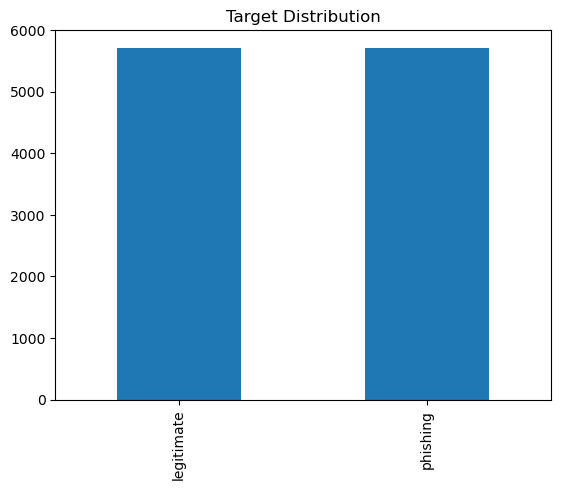

In [14]:
df['status'].value_counts().plot(kind='bar')

plt.title("Target Distribution")

plt.show()


In [15]:
df['length_url'].describe()


count    11430.000000
mean        61.126684
std         55.297318
min         12.000000
25%         33.000000
50%         47.000000
75%         71.000000
max       1641.000000
Name: length_url, dtype: float64

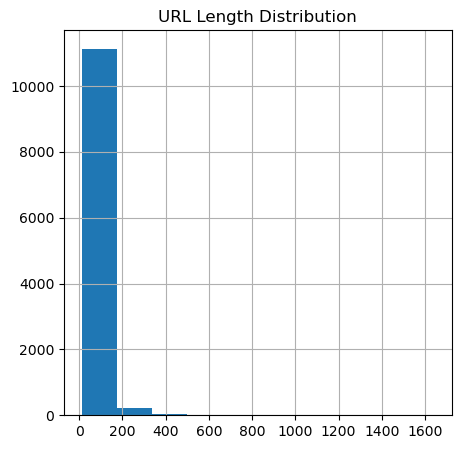

In [19]:
plt.figure(figsize=(5,5))

df['length_url'].hist()

plt.title("URL Length Distribution")

plt.show()


In [20]:
df['domain_age'].describe()



count    11430.000000
mean      4062.543745
std       3107.784600
min        -12.000000
25%        972.250000
50%       3993.000000
75%       7026.750000
max      12874.000000
Name: domain_age, dtype: float64

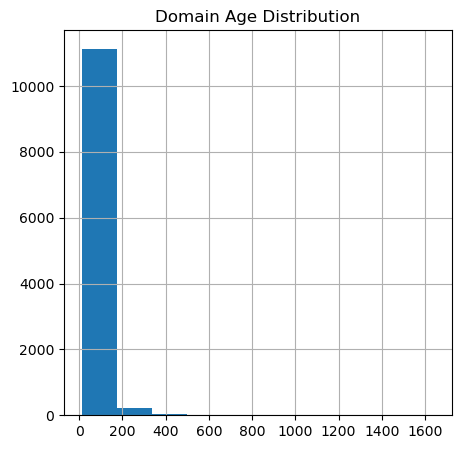

In [21]:
plt.figure(figsize=(5,5))

df['length_url'].hist()

plt.title("Domain Age Distribution")

plt.show()


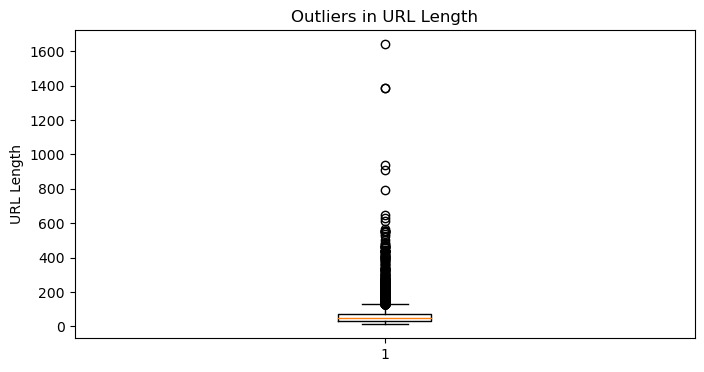

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.boxplot(df['length_url'])

plt.title("Outliers in URL Length")
plt.ylabel("URL Length")

plt.show()



In [23]:
Q1 = df['length_url'].quantile(0.25)
Q3 = df['length_url'].quantile(0.75)

IQR = Q3-Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['length_url'] < lower_limit) | (df['length_url'] > upper_limit)]

print("Number of Outliers:",len(outliers))

Number of Outliers: 620


In [27]:
print(df['status'].unique())

['legitimate' 'phishing']


In [28]:
df['status'] = df['status'].map({
    'legitimate': 0,
    'phishing': 1
})


In [29]:
corr_with_target = df.corr()['status']

print(corr_with_target.sort_values(ascending=False))

status                  1.000000
google_index            0.731171
ratio_digits_url        0.356395
domain_in_title         0.342807
phish_hints             0.335393
                          ...   
ratio_nullHyperlinks         NaN
ratio_intRedirection         NaN
ratio_intErrors              NaN
submit_email                 NaN
sfh                          NaN
Name: status, Length: 88, dtype: float64


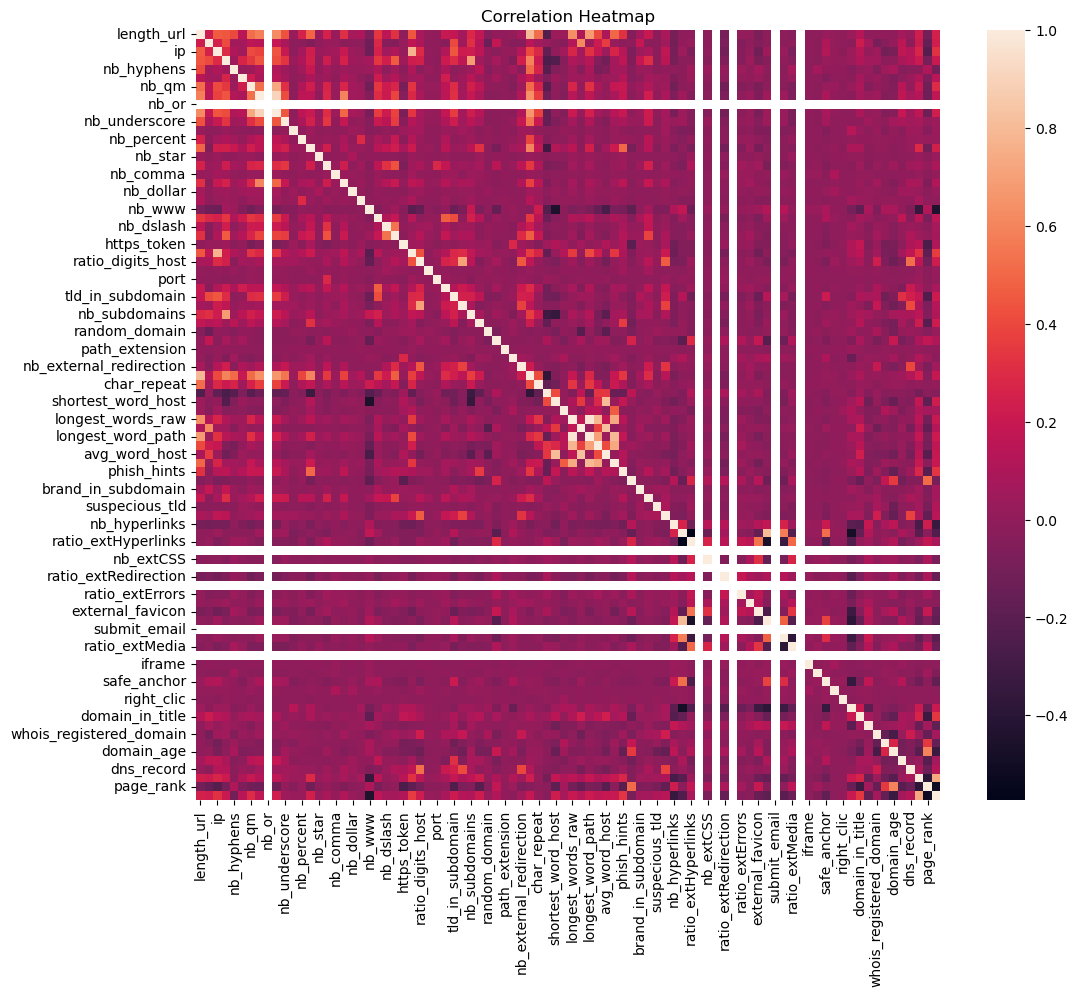

In [32]:
import matplotlib.pyplot as plt 
import seaborn as sns

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,10))

sns.heatmap(numeric_df.corr())

plt.title("Correlation Heatmap")

plt.show()